# Tutorial 02 — Gasificador 0D: Semibatch — 4 modos de outlet

**Equipo:** Gasificador de lecho fijo · **Modo:** 0D (N=1) · Semibatch  
**Fenómeno:** Pirólisis de biomasa con distintas estrategias de control de la salida de gas  
**Prerrequisito:** Tutorial 01 — Gasificador 0D Batch

## Introducción

Este tutorial extiende el Tutorial 01 explorando **cuatro estrategias de outlet** para el semibatch.
El resto del sistema es idéntico: reactor 0D, biomasa seca, calefacción externa a 800 °C, sin entrada de agente gasificante.

### Los 4 modos de outlet

| Caso | `v_out` | `Cv` | Física | ¿P ≈ P_out? |
|------|---------|------|--------|-------------|
| **A — Batch sellado** | `0.0` | None | Sin salida. Gas acumulado, P libre | No — P sube |
| **B — Venteo proporcional** | `0.05` | None | $v_{out} = \max(0,\,(P-P_{out})/P_{out})\cdot v_{out}$ | Parcial |
| **C — Isobaro exacto** | `None` | None | $v_{out} = F_{rxn}/C_{tot,target}$ | **Sí** |
| **D — Válvula ISA** | None | `0.5` | $Q \propto C_v\sqrt{\Delta P \cdot P_{up}/(T_{up}\cdot S_g)}$ | Aproximado |

- El **caso A** es la referencia: el reactor está sellado y la presión sube libremente.
- El **caso B** alivia presión cuando P > P_out, pero de forma proporcional.
- El **caso C** es isobaro exacto: el balance molar evacua exactamente lo que generan las reacciones.
- El **caso D** usa una válvula ISA-75.01: caudal en función de ΔP y densidad del gas.

### Qué observar

1. **Presión** vs t: cómo cada modo controla (o no) la presión.
2. **v_out** vs t: el perfil de apertura de la salida.
3. **Composición del gas**: las reacciones son las mismas — ¿cambia la composición?
4. **Balances**: todos los modos deben cerrar con residual < 1 %.

In [28]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

# Ajustar ruta al raíz del proyecto (test/gasifier/ → ../../)
ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from src.io.fuels_reader import read_fueldb
from src.units.gasifier.config.gas_props    import build_gas_prop_config, GASIFIER_GAS_SPECIES
from src.units.gasifier.config.solid_props  import build_solid_prop_config
from src.units.gasifier.config.transport    import build_transport_config
from src.units.gasifier.config.thermal_bc   import build_thermal_bc_config
from src.units.gasifier.config.boundary_c   import build_bc_config
from src.units.gasifier.config.initial_c    import build_initial_c_config
from src.solvers.runner_gasifier            import run_step
from src.postprocessing.gasifier_balances   import check_balances, display_balances
from src.postprocessing.gasifier_plots      import (
    plot_temperatures, plot_solid_evolution,
    plot_gas_composition, plot_pressure,
)

print(f"ROOT: {ROOT}")

ROOT: C:\Users\MiguelCamaraSanz\OneDrive - Fundacion CIRCE\GITHUB\ProSimNet-gasifier


## 1. Bases de datos y propiedades del combustible

In [29]:
# Rutas a bases de datos
FUEL_PATH = os.path.join(ROOT, "materials", "fuels", "softwood_spruce.yaml")
GAS_DB    = os.path.join(ROOT, "materials", "fluids", "gasdb.txt")
SOLID_DB  = os.path.join(ROOT, "materials", "solids", "soliddb.txt")

# Carga del combustible
fuel_config = read_fueldb(FUEL_PATH)

# Resumen del combustible cargado
rho_p = float(fuel_config["physical"]["rho_particle"])   # [kg/m³]
dp0   = float(fuel_config["physical"]["dp_initial"])     # [m]
print(f"Combustible : {fuel_config['description']}")
print(f"ρ_partícula : {rho_p:.0f} kg/m³")
print(f"dp_inicial  : {dp0*1000:.1f} mm")

Combustible : Softwood (spruce) for fixed-bed updraft gasification
ρ_partícula : 430 kg/m³
dp_inicial  : 10.0 mm


## 2. Geometría y condiciones de operación

Mismo reactor del Tutorial 01: tubo de ≈ 785 cm³ calentado externamente.
Geometría y carga de sólido idénticas para que la comparación sea directa.

In [30]:
# ── Geometría ─────────────────────────────────────────────────────────────────
N  = 1       # Número de celdas → modelo 0D (volumen perfectamente mezclado)
L  = 0.10    # [m]  longitud del reactor
Di = 0.10    # [m]  diámetro interno
Do = 0.114   # [m]  diámetro externo (e_pared = 7 mm, acero inox 316L)

dz     = L / N                     # [m]   tamaño de celda
Ai     = 0.25 * np.pi * Di**2      # [m²]  sección transversal interna
Pi     = np.pi * Di                # [m]   perímetro interno
Po     = np.pi * Do                # [m]   perímetro externo
e_wall = (Do - Di) / 2             # [m]   espesor de pared

# ── Condiciones de operación ──────────────────────────────────────────────────
epsi_r = 0.60       # [-]   porosidad del lecho (fracción de huecos gas/volumen lecho)
P_out  = 1.01325    # [bar] presión de referencia (salida de la válvula de alivio)

# ── Carga inicial de biomasa ──────────────────────────────────────────────────
mc_wb       = 0.15                                          # [-]         contenido de humedad base húmeda
rho_bio_dry = rho_p * (1 - epsi_r)                          # [kg/m³_bed] biomasa seca en lecho
rho_moi_0   = rho_bio_dry * mc_wb / (1 - mc_wb)             # [kg/m³_bed] humedad inicial
rho_bio_0   = rho_bio_dry                                   # [kg/m³_bed] biomasa inicial
rho_char_0  = 1e-6                                          # [kg/m³_bed] traza de char inicial

# Densidad de referencia del char (para modelo de partícula decreciente SCM)
rho_char0 = fuel_config["pyrolysis_yields"]["char"] * rho_p * (1 - epsi_r)

print(f"Geometría:")
print(f"  N = {N} celdas → modelo 0D")
print(f"  V_reactor = {Ai*L*1e6:.1f} cm³  (Di={Di*100:.0f} cm, L={L*100:.0f} cm)")
print(f"\nCarga inicial de sólido:")
print(f"  ρ_biomasa  = {rho_bio_0:.1f} kg/m³_bed")
print(f"  ρ_humedad  = {rho_moi_0:.1f} kg/m³_bed  ({mc_wb*100:.0f} % wb)")
print(f"  ρ_char_ini = {rho_char_0:.1e} kg/m³_bed  (traza)")

Geometría:
  N = 1 celdas → modelo 0D
  V_reactor = 785.4 cm³  (Di=10 cm, L=10 cm)

Carga inicial de sólido:
  ρ_biomasa  = 172.0 kg/m³_bed
  ρ_humedad  = 30.4 kg/m³_bed  (15 % wb)
  ρ_char_ini = 1.0e-06 kg/m³_bed  (traza)


## 3. Condiciones iniciales del gas

Igual que en el Tutorial 01: N₂ puro a temperatura ambiente (300 K) y presión atmosférica.

In [31]:
T_init = 300.0    # [K] temperatura inicial de gas y sólido (≈ 27 °C)

species = list(GASIFIER_GAS_SPECIES)   # ['CO','CO2','H2O','H2','O2','CH4','C2H4','tar','N2']
nc      = len(species)                 # 9 especies

y0 = np.zeros(nc)
y0[species.index("N2")] = 1.0    # 100 % N₂ al inicio

print(f"Temperatura inicial: {T_init:.1f} K ({T_init-273.15:.1f} °C)")
print(f"Composición inicial: 100 % N₂")
print(f"Presión inicial    : {P_out:.5f} bar")

Temperatura inicial: 300.0 K (26.9 °C)
Composición inicial: 100 % N₂
Presión inicial    : 1.01325 bar


## 4. Condición térmica (común a todos los casos)

Pared a temperatura fija de 800 °C, igual que en el Tutorial 01.
La condición térmica no varía entre los dos casos — solo cambia el modo de la salida del gas.

In [32]:
T_wall   = 1073.15    # [K] = 800 °C — temperatura de la pared exterior
k_wall   = 16.5       # [W/m/K]  conductividad térmica acero inoxidable 316L
rho_wall = 7950.0     # [kg/m³]  densidad acero inoxidable 316L
Cp_wall  = 510.0      # [J/kg/K] calor específico acero inoxidable 316L

tbc_cfg = build_thermal_bc_config(
    mode     = "fixed_twall",
    Di       = Di,
    Do       = Do,
    e_wall   = e_wall,
    T_wall   = T_wall,
    k_wall   = k_wall,
    rho_wall = rho_wall,
    Cp_wall  = Cp_wall,
)

print(f"BC térmica: pared fija  T_wall = {T_wall:.2f} K ({T_wall-273.15:.1f} °C)")
print(f"Material  : k={k_wall} W/m/K  ρ={rho_wall:.0f} kg/m³  Cp={Cp_wall:.0f} J/kg/K")

BC térmica: pared fija  T_wall = 1073.15 K (800.0 °C)
Material  : k=16.5 W/m/K  ρ=7950 kg/m³  Cp=510 J/kg/K


## 5. Propiedades y modelo de transporte

In [33]:
# ── Propiedades del gas (modo polinomial: Cp, µ, k dependientes de T) ──────────
prop_gas  = build_gas_prop_config(fuel_config=fuel_config, mode="polynomial", db_path=GAS_DB)
gas_T_ref = float(np.min(np.asarray(prop_gas["Tref"])))   # [K] temperatura de referencia de entalpía
MW_arr    = np.asarray(prop_gas["MW"])                     # [kg/mol]

# ── Propiedades del sólido (Cp_fns y h_fns como funciones de T) ────────────────
solid_config = build_solid_prop_config(fuel_config)

# ── Modelo de transporte: constante ────────────────────────────────────────────
trans_cfg = build_transport_config(
    mode   = "constant",
    N      = N,
    n_comp = nc,
    h_bed  = 80.0,    # [W/m²/K] coeficiente gas-partícula
    h_wall = 20.0,    # [W/m²/K] coeficiente gas-pared
)

print(f"gas_T_ref = {gas_T_ref:.2f} K  (referencia de entalpía)")
print(f"Transporte: constante  (h_bed=80, h_wall=20 W/m²/K)")

gas_T_ref = 298.00 K  (referencia de entalpía)
Transporte: constante  (h_bed=80, h_wall=20 W/m²/K)


## 6. Vector de estado inicial (sv0)

El mismo sv0 sirve para los 4 casos, ya que las condiciones iniciales son idénticas.

```
sv0 = [C(nc×N), ρ_s(3×N), Hg(N), Ts(N), Q_mt_acc(N), Q_rxn_acc(N), Q_gs_acc(N)]
      └── 9N ──┘└── 3N ──┘└─ N ┘└─ N ┘└────── N ─────┘└────── N ──┘└────── N ──┘
                                                                    total = 17×N
```

Para N=1: `sv0.shape = (17,)`

In [34]:
init_cfg = build_initial_c_config(
    P_init            = P_out,
    Tg_init           = T_init,
    Ts_init           = T_init,
    y_init            = y0,
    rho_biomass_init  = rho_bio_0,
    rho_char_init     = rho_char_0,
    rho_moisture_init = rho_moi_0,
    n_comp            = nc,
    N                 = N,
    prop_gas          = prop_gas,
    epsi_r            = epsi_r,
    gas_T_ref         = gas_T_ref,
    Tw_init           = None,    # Sin modelo dinámico de pared
)

sv0 = init_cfg["sv0"]
print(f"sv0.shape = {sv0.shape}   ({sv0.shape[0] // N} × {N} = {sv0.shape[0]} DOFs)")

sv0.shape = (17,)   (17 × 1 = 17 DOFs)


## 7. Parámetros base (comunes a los 4 casos)

El diccionario `params_base` contiene todos los parámetros compartidos. La clave `bc_config`
se añadirá por separado en cada caso, ya que es el único parámetro que cambia.

In [35]:
params_base = {
    # Geometría
    "n_comp" : nc,
    "N"      : N,
    "dz"     : dz,
    "Ai"     : Ai,
    "Di"     : Di,
    "Pi"     : Pi,
    "Po"     : Po,
    # Propiedades del gas
    "prop_gas"   : prop_gas,
    "MW"         : MW_arr,
    "gas_T_ref"  : gas_T_ref,
    # Configuraciones compartidas
    "trans_config"     : trans_cfg,
    "thermal_bc_config": tbc_cfg,
    "energy"           : True,
    # Específico del gasificador
    "epsi_r"      : epsi_r,
    "dp0"         : dp0,
    "rho_char0"   : rho_char0,
    "fuel_config" : fuel_config,
    "solid_config": solid_config,
    "species"     : species,
    # bc_config no está aquí → se añade en cada caso
}

---
## 8. Simulaciones principales — 4 modos de outlet

Se ejecutan los 4 casos con el mismo setup (sv0, params_base, tbc_cfg ya definidos).
El tiempo de simulación es el mismo para todos; `T_MAX` se define una sola vez.

In [36]:
T_MAX = 600.0    # [s] tiempo de simulación compartido por los 4 casos

### 8.A — Batch sellado (`v_out = 0.0`) — referencia

El reactor está sellado: ningún gas sale. Toda la producción interna de pirólisis y secado
queda en el volumen de control → P sube libremente mientras duran las reacciones.

In [37]:
bc_cfg_A  = build_bc_config(n_comp=nc, P_out_bar=P_out, v_out=0.0)
params_A  = {**params_base, "bc_config": bc_cfg_A}

print("=" * 60)
print("Caso A — Batch sellado  (v_out = 0.0)")
print("=" * 60)
t_A, _, gasifier_A = run_step(sv0=sv0, t_max=T_MAX, params=params_A,
                               rtol=1e-5, atol=1e-7, n_sec=5, show_progress=True)

P_max_A = float(gasifier_A._P_results.max())
print(f"\n✓  t_final={t_A[-1]:.0f} s  |  P_max={P_max_A:.3f} bar ({P_max_A/P_out:.2f}×P_out)"
      f"  |  Ts_fin={gasifier_A._Ts_results[-1,0]-273.15:.0f} °C")

Caso A — Batch sellado  (v_out = 0.0)


gasifier:   0%|          | 0.0/600 s [00:00<?, ?s/s]


✓  t_final=600 s  |  P_max=224.151 bar (221.22×P_out)  |  Ts_fin=345 °C


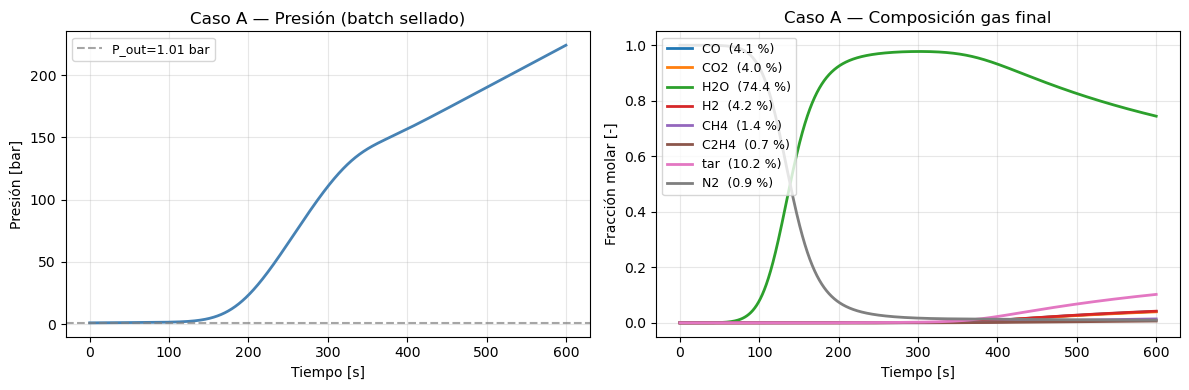

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_pressure(gasifier_A, ax=axes[0])
axes[0].axhline(P_out, ls="--", color="gray", alpha=0.7, label=f"P_out={P_out:.2f} bar")
axes[0].set_title("Caso A — Presión (batch sellado)")
axes[0].legend(fontsize=9)

plot_gas_composition(gasifier_A, ax=axes[1])
axes[1].set_title("Caso A — Composición gas final")
fig.tight_layout(); plt.show()

### 8.B — Venteo proporcional (`v_out = 0.05 m/s`)

La válvula alivia gas cuando P > P_out con una velocidad proporcional al exceso de presión.
`v_out = 0.05 m/s` es un valor intermedio: la presión oscila en torno a P_out pero puede
subir moderadamente antes de que la válvula abra.

In [39]:
bc_cfg_B  = build_bc_config(n_comp=nc, P_out_bar=P_out, v_out=0.05)
params_B  = {**params_base, "bc_config": bc_cfg_B}

print("=" * 60)
print("Caso B — Venteo proporcional  (v_out = 0.05 m/s)")
print("=" * 60)
t_B, _, gasifier_B = run_step(sv0=sv0, t_max=T_MAX, params=params_B,
                               rtol=1e-5, atol=1e-7, n_sec=5, show_progress=True)

P_max_B = float(gasifier_B._P_results.max())
print(f"\n✓  t_final={t_B[-1]:.0f} s  |  P_max={P_max_B:.3f} bar ({P_max_B/P_out:.2f}×P_out)"
      f"  |  Ts_fin={gasifier_B._Ts_results[-1,0]-273.15:.0f} °C")

Caso B — Venteo proporcional  (v_out = 0.05 m/s)


gasifier:   0%|          | 0.0/600 s [00:00<?, ?s/s]


✓  t_final=600 s  |  P_max=1.963 bar (1.94×P_out)  |  Ts_fin=346 °C


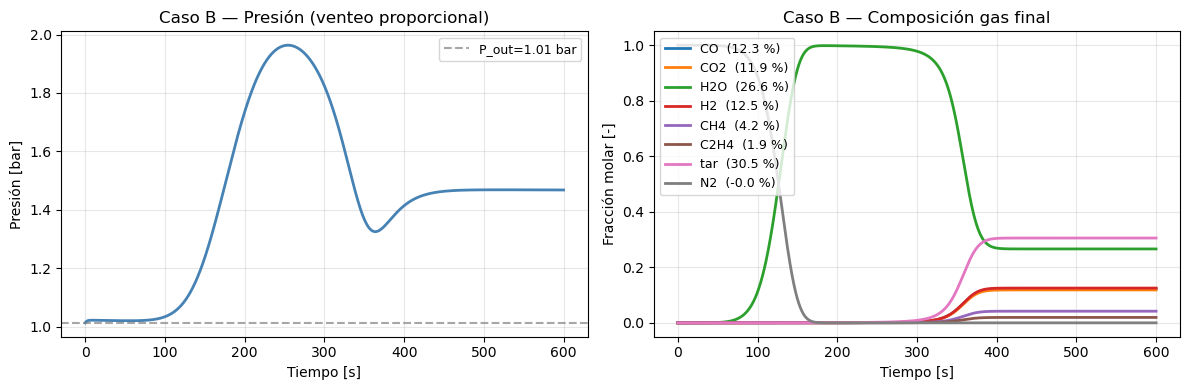

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_pressure(gasifier_B, ax=axes[0])
axes[0].axhline(P_out, ls="--", color="gray", alpha=0.7, label=f"P_out={P_out:.2f} bar")
axes[0].set_title("Caso B — Presión (venteo proporcional)")
axes[0].legend(fontsize=9)

plot_gas_composition(gasifier_B, ax=axes[1])
axes[1].set_title("Caso B — Composición gas final")
fig.tight_layout(); plt.show()

### 8.C — Isobaro exacto (`v_out = None`)

Con `v_out=None` la salida evacua exactamente lo que generan las reacciones:

$$v_{out} = \frac{F_{rxn}}{C_{tot,target}}, \qquad F_{rxn} = \sum_i \text{source}_i \cdot \varepsilon \cdot dz \;\;[\text{mol/m}^2\text{/s}]$$

La presión debería mantenerse en P_out desde el inicio de las reacciones.

In [41]:
bc_cfg_C  = build_bc_config(n_comp=nc, P_out_bar=P_out)   # v_out=None por defecto
params_C  = {**params_base, "bc_config": bc_cfg_C}

print("=" * 60)
print("Caso C — Isobaro exacto  (v_out = None)")
print("=" * 60)
t_C, _, gasifier_C = run_step(sv0=sv0, t_max=T_MAX, params=params_C,
                               rtol=1e-5, atol=1e-7, n_sec=5, show_progress=True)

P_max_C = float(gasifier_C._P_results.max())
print(f"\n✓  t_final={t_C[-1]:.0f} s  |  P_max={P_max_C:.3f} bar ({P_max_C/P_out:.4f}×P_out)"
      f"  |  Ts_fin={gasifier_C._Ts_results[-1,0]-273.15:.0f} °C")

Caso C — Isobaro exacto  (v_out = None)


gasifier:   0%|          | 0.0/600 s [00:00<?, ?s/s]


✓  t_final=600 s  |  P_max=1.013 bar (1.0000×P_out)  |  Ts_fin=346 °C


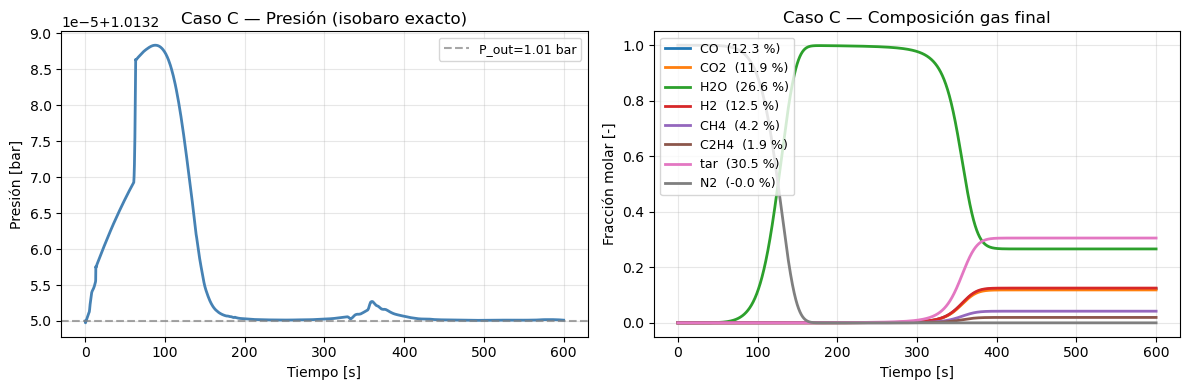

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_pressure(gasifier_C, ax=axes[0])
axes[0].axhline(P_out, ls="--", color="gray", alpha=0.7, label=f"P_out={P_out:.2f} bar")
axes[0].set_title("Caso C — Presión (isobaro exacto)")
axes[0].legend(fontsize=9)

plot_gas_composition(gasifier_C, ax=axes[1])
axes[1].set_title("Caso C — Composición gas final")
fig.tight_layout(); plt.show()

### 8.D — Válvula ISA-75.01 (`Cv = 0.5`)

La válvula ISA usa la fórmula de orificio: el caudal depende de ΔP y de la densidad
del gas (temperatura y composición). Es el modelo de válvula más realista de los 4.
`Cv = 0.5` es el coeficiente de caudal de la válvula (tamaño medio).

In [43]:
bc_cfg_D  = build_bc_config(n_comp=nc, P_out_bar=P_out, Cv=0.5)
params_D  = {**params_base, "bc_config": bc_cfg_D}

print("=" * 60)
print("Caso D — Válvula ISA-75.01  (Cv = 0.5)")
print("=" * 60)
t_D, _, gasifier_D = run_step(sv0=sv0, t_max=T_MAX, params=params_D,
                               rtol=1e-5, atol=1e-7, n_sec=5, show_progress=True)

P_max_D = float(gasifier_D._P_results.max())
print(f"\n✓  t_final={t_D[-1]:.0f} s  |  P_max={P_max_D:.3f} bar ({P_max_D/P_out:.4f}×P_out)"
      f"  |  Ts_fin={gasifier_D._Ts_results[-1,0]-273.15:.0f} °C")

Caso D — Válvula ISA-75.01  (Cv = 0.5)


gasifier:   0%|          | 0.0/600 s [00:00<?, ?s/s]


✓  t_final=600 s  |  P_max=1.018 bar (1.0046×P_out)  |  Ts_fin=346 °C


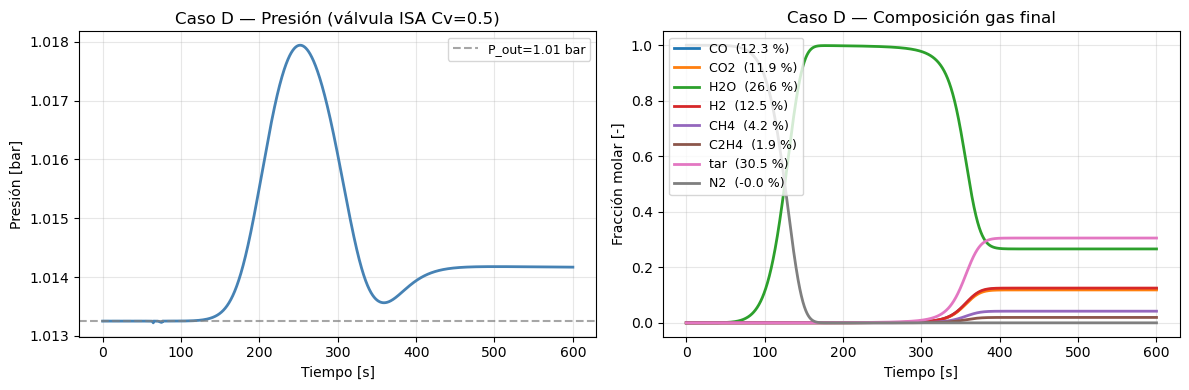

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_pressure(gasifier_D, ax=axes[0])
axes[0].axhline(P_out, ls="--", color="gray", alpha=0.7, label=f"P_out={P_out:.2f} bar")
axes[0].set_title("Caso D — Presión (válvula ISA Cv=0.5)")
axes[0].legend(fontsize=9)

plot_gas_composition(gasifier_D, ax=axes[1])
axes[1].set_title("Caso D — Composición gas final")
fig.tight_layout(); plt.show()

---
## 9. Comparación de los 4 modos de outlet

Las curvas siguientes superponen los 4 casos con el mismo setup y la misma duración.
El objetivo es ver claramente cómo cada estrategia de outlet controla (o no) la presión.

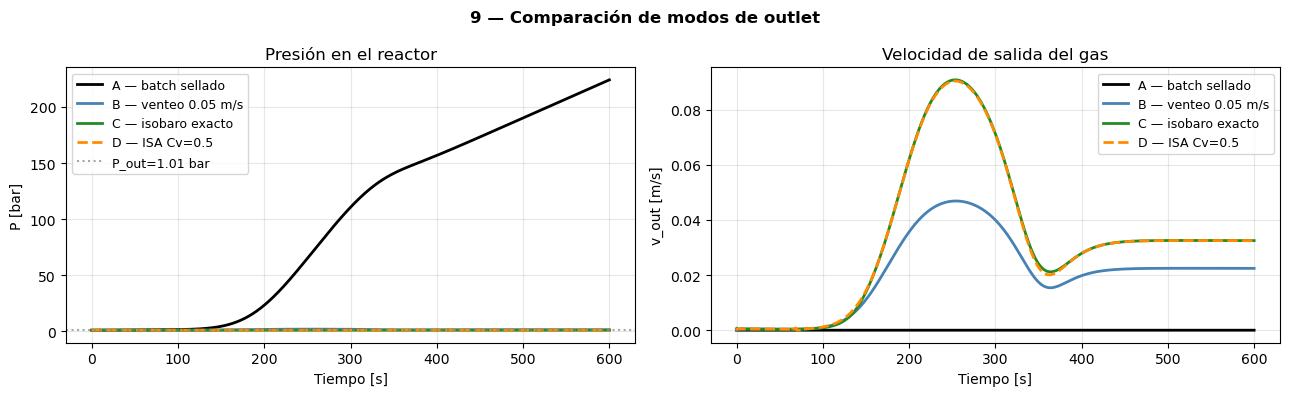

In [45]:
casos  = [(t_A, gasifier_A, "A — batch sellado",       "black",       "-"),
          (t_B, gasifier_B, "B — venteo 0.05 m/s",     "steelblue",   "-"),
          (t_C, gasifier_C, "C — isobaro exacto",       "forestgreen", "-"),
          (t_D, gasifier_D, "D — ISA Cv=0.5",           "darkorange",  "--")]

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=True)
for t_, g_, lbl, col, ls in casos:
    axes[0].plot(t_, g_._P_results[:, 0],  color=col, lw=2, ls=ls, label=lbl)
    axes[1].plot(t_, g_._v_out_results,    color=col, lw=2, ls=ls, label=lbl)

axes[0].axhline(P_out, ls=":", color="gray", alpha=0.7, label=f"P_out={P_out:.2f} bar")
axes[0].set(xlabel="Tiempo [s]", ylabel="P [bar]", title="Presión en el reactor")
axes[1].set(xlabel="Tiempo [s]", ylabel="v_out [m/s]", title="Velocidad de salida del gas")
for ax in axes: ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
fig.suptitle("9 — Comparación de modos de outlet", fontweight="bold")
fig.tight_layout(); plt.show()

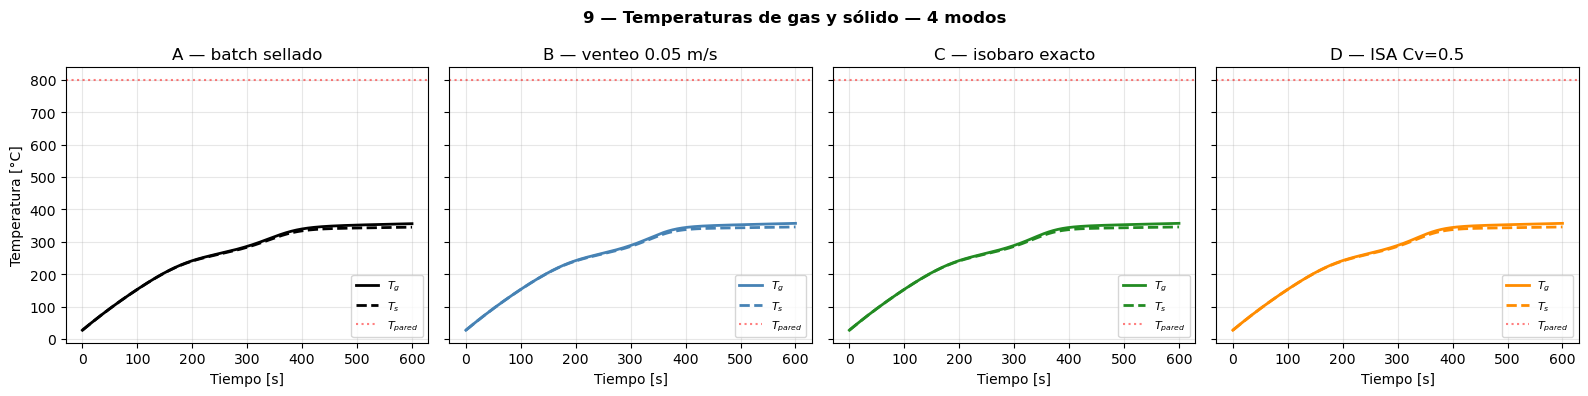

In [46]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
for ax, (t_, g_, lbl, col, _) in zip(axes, casos):
    ax.plot(t_, g_._Tg_results[:, 0]-273.15, color=col, lw=2,       label="$T_g$")
    ax.plot(t_, g_._Ts_results[:, 0]-273.15, color=col, lw=2, ls="--", label="$T_s$")
    ax.axhline(T_wall-273.15, ls=":", color="red", alpha=0.5, label="$T_{pared}$")
    ax.set(xlabel="Tiempo [s]", title=lbl)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
axes[0].set_ylabel("Temperatura [°C]")
fig.suptitle("9 — Temperaturas de gas y sólido — 4 modos", fontweight="bold")
fig.tight_layout(); plt.show()

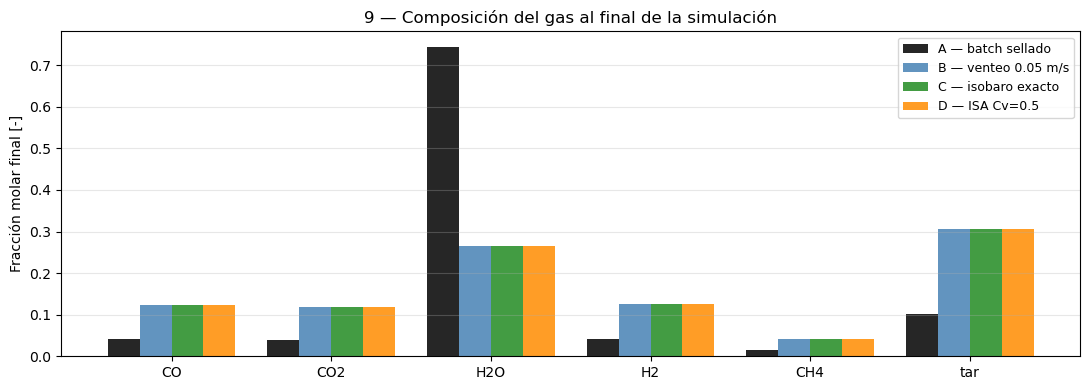

In [47]:
# Fracciones molares finales — barras lado a lado
sp_show   = ["CO", "CO2", "H2O", "H2", "CH4", "tar"]
n_sp      = len(sp_show)
x_base    = np.arange(n_sp)
width     = 0.20

fig, ax = plt.subplots(figsize=(11, 4))
for k, (_, g_, lbl, col, _) in enumerate(casos):
    yf = [float(g_._y_results[-1, species.index(s), 0]) for s in sp_show]
    ax.bar(x_base + k*width, yf, width, label=lbl, color=col, alpha=0.85)

ax.set_xticks(x_base + 1.5*width)
ax.set_xticklabels(sp_show)
ax.set(ylabel="Fracción molar final [-]", title="9 — Composición del gas al final de la simulación")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis="y")
fig.tight_layout(); plt.show()

---
## 10. Verificación de balances

Los 4 modos deben cerrar con los mismos cierres numéricos (★).
La diferencia está en los residuales físicos (Fuente_rxn, masa sólida),
que reflejan cuánto reaccionó y cuánto gas salió por la válvula.

In [48]:
for lbl, g_, p_ in [
    ("A — batch sellado   (v_out=0.0)",   gasifier_A, params_A),
    ("B — venteo 0.05 m/s (v_out=0.05)",  gasifier_B, params_B),
    ("C — isobaro exacto  (v_out=None)",  gasifier_C, params_C),
    ("D — ISA Cv=0.5",                    gasifier_D, params_D),
]:
    print(f"\n{'='*60}")
    print(f"Balances — Caso {lbl}")
    print(f"{'='*60}")
    bal = check_balances(g_, p_, verbose=False)
    display_balances(bal)


Balances — Caso A — batch sellado   (v_out=0.0)
── ★ Masa total [kg/m³] ──────────────────────────────────────────────


,Valor [kg/m³],Tipo
Término,,
Δm_gas,+5.8144e+01,
Δm_sólido,-5.8144e+01,
Flujo_masa_neto,+0.0000e+00,
★ Cierre,+2.8296e-05,0.000 % ✓ OK



── ~ Especies gas [mol/m³ | kg/m³]  (Fuente_rxn ≠ 0 esperado — residual físico; ★ Cierre ≈ 0) ─
   Formato: mol/m³  /  kg/m³  |  TOTAL kg/m³ ≈ Δm_gas del balance de masa  |  ★ Cierre ≈ 0 por construcción


,ΔC [mol | kg/m³],Flujo [mol | kg/m³],~ Fuente_rxn [mol | kg/m³],★ Cierre [mol | kg/m³]
CO,+1.062e+02 / +2.975e+00,+0.000e+00 / +0.000e+00,+1.062e+02 / +2.975e+00,+0.000e+00 / +0.000e+00
CO2,+1.022e+02 / +4.499e+00,+0.000e+00 / +0.000e+00,+1.022e+02 / +4.499e+00,+0.000e+00 / +0.000e+00
H2O,+1.914e+03 / +3.449e+01,+0.000e+00 / +0.000e+00,+1.914e+03 / +3.449e+01,+0.000e+00 / +0.000e+00
H2,+1.080e+02 / +2.177e-01,+0.000e+00 / +0.000e+00,+1.080e+02 / +2.177e-01,+0.000e+00 / +0.000e+00
O2,-3.600e-15 / -1.152e-16,+0.000e+00 / +0.000e+00,-3.600e-15 / -1.152e-16,+0.000e+00 / +0.000e+00
CH4,+3.618e+01 / +5.805e-01,+0.000e+00 / +0.000e+00,+3.618e+01 / +5.805e-01,+0.000e+00 / +0.000e+00
C2H4,+1.681e+01 / +4.716e-01,+0.000e+00 / +0.000e+00,+1.681e+01 / +4.716e-01,+0.000e+00 / +0.000e+00
tar,+2.634e+02 / +1.491e+01,+0.000e+00 / +0.000e+00,+2.634e+02 / +1.491e+01,+0.000e+00 / +0.000e+00
N2,+0.000e+00 / +0.000e+00,+0.000e+00 / +0.000e+00,+0.000e+00 / +0.000e+00,+0.000e+00 / +0.000e+00
── TOTAL ──,+2.547e+03 / +5.814e+01,+0.000e+00 / +0.000e+00,+2.547e+03 / +5.814e+01,+0.000e+00 / +0.000e+00



── ~ Masa sólida [kg/m³]  (S_rxn = masa transformada por reacciones — residual físico esperado ≠ 0) ──────


...

,Valor [J/m³],Nota
Término,,
ΔHg,+2.3515e+05,acumulación gas
Fh_conv_neto,-1.2567e+08,exacto
Q_gs (gas→sólido),+2.5649e+08,acum. ODE — exacto
Q_wall (pared→gas),+2.5728e+08,thermal_bc
Q_mt (sól→gas),+1.2512e+08,acum. ODE — exacto
★ Cierre_Hg,-5.3734e+03,-0.002 % ✓ OK



── ★ Energía sólido  Ts [J/m³] ──────────────────────────────────────────


,Valor [J/m³],Nota
Término,,
"ΔHs [∫Cp dT, exacto]",+8.1778e+07,Σ ρⱼ·H_j(Ts)
Q_gs (gas→sólido),+2.5649e+08,acum. ODE — exacto
Q_rxn (exacto),-1.7471e+08,acum. ODE — exacto
★ Cierre_Hs,+1.6302e+02,0.000 % ✓ OK



── ★ Balance global  Hg+Hs [J/m³] ──────────────────────────────────────


,Valor [J/m³],Nota
Término,,
ΔHg + ΔHs,+8.2014e+07,acumulación total
Fh_conv_neto,-1.2567e+08,exacto
Q_wall,+2.5728e+08,thermal_bc
Q_rxn (exacto),-1.7471e+08,acum. ODE
Q_mt (exacto),+1.2512e+08,acum. ODE
★ Cierre global,-5.2104e+03,-0.002 % ✓ OK


## Interpretación de balances

**★ Cierre numérico** — residual debe ser ≈ 0 (umbral: < 1 % del término mayor)  
**~ Residual físico** — residual = cantidad producida o consumida; se espera ≠ 0

### Diferencias esperadas entre los 4 casos

| Balance | A (sellado) | B (venteo) | C (isobaro) | D (ISA) |
|---------|-------------|------------|-------------|---------|
| Flujo neto masa | 0 | ≠ 0 (gas sale) | ≠ 0 | ≠ 0 |
| ~ Fuente_rxn total [kg] | = \|Δm_sólido\| | < \|Δm_sólido\| | ≪ \|Δm_sólido\| | < \|Δm_sólido\| |
| ★ Cierre masa total | ≈ 0 | ≈ 0 | ≈ 0 | ≈ 0 |
| ★ Cierre Hg | ≈ 0 | ≈ 0 | ≈ 0 | ≈ 0 |
| ★ Cierre Hs | ≈ 0 | ≈ 0 | ≈ 0 | ≈ 0 |
| ★ Balance global | ≈ 0 | ≈ 0 | ≈ 0 | ≈ 0 |

En el **caso A (sellado)** nada sale → `Flujo = 0` y `Fuente_rxn = ΔC` exactamente.  
En los casos B, C, D → parte del gas producido ya salió: `Fuente_rxn < ΔC` (se compensó con `Flujo`).  
En el **caso C (isobaro)**, el gas sale casi instantáneamente → `Fuente_rxn` ≪ `ΔC` y `Flujo` es grande.

Si algún ★ supera el 1 %: reducir `max_step` o ajustar `rtol`/`atol`.

## Conclusiones

### Qué demuestra este tutorial

1. **Batch sellado (A)**: referencia. P sube libremente mientras hay reacciones; todo el gas
   producido queda en el reactor. La composición final refleja el equilibrio cinético sin
   pérdidas de masa.

2. **Venteo proporcional (B)**: alivia presión cuando P > P_out, pero la apertura es gradual.
   P puede subir varios bar antes de que la válvula abra lo suficiente.

3. **Isobaro exacto (C)**: P ≈ P_out en todo momento. La salida evacua exactamente lo que
   generan las reacciones por balance molar. Es el modo más físicamente "limpio" para
   estudiar pirólisis a presión controlada.

4. **Válvula ISA (D)**: modelo de válvula real. El caudal depende de ΔP y de la densidad
   del gas (temperatura, composición). Más realista que el venteo proporcional.

5. **Las reacciones son las mismas en los 4 casos**: lo que cambia es cuánto gas se acumula
   y a qué presión opera el reactor. Las fracciones molares finales son similares; las
   concentraciones absolutas [mol/m³] son muy distintas.

6. **Los balances ★ cierran en los 4 modos**: el mecanismo de outlet no rompe los cierres.

### Qué probar a continuación (sección 11)

- **11.A T_wall**: ¿a qué temperatura arranca la pirólisis? Usar `v_out=None` (isobaro).
- **11.B mc_wb**: efecto de la humedad en el balance energético.
- **11.C T_MAX**: ¿cuándo se agota la biomasa?
- **11.D Barrido v_out + isobaro**: comparación sistemática de velocidades de venteo.
- **11.E Barrido Cv**: respuesta de la válvula ISA según su coeficiente.
- **11.F P_out**: efecto de la presión de consigna.

---
## 11. Análisis paramétrico

Esta sección explora el efecto de los parámetros más relevantes del semibatch
en modo **isobaro** (`v_out=None`): la presión se mantiene en P_out en todo momento,
lo que elimina la hidráulica como variable de confusión en la comparación.

| Estudio | Variable | Valores explorados |
|---------|----------|-------------------|
| 11.A | T_wall [K] | 700, 900, 1073, 1200 K |
| 11.B | mc_wb [-] | 0 %, 15 %, 30 % |
| 11.C | T_MAX [s] | 1200, 2400, 3600 s |
| 11.D | v_out [m/s] | 0.0 (sellado), 0.01, 0.05, 0.50, None (isobaro) |
| 11.F | Cv [-] | 0.05, 0.5, 2.0, 10.0 |
| 11.G | P_out [bar] | 1.01325, 2.0, 5.0 bar |

Referencia común para todos los estudios (salvo donde se indica): T_wall=1073 K,
`v_out=None` (isobaro), T_MAX=600 s, mc_wb=0.15, P_out=1.01325 bar.

### 11.A — Efecto de la temperatura de pared (T_wall)

¿A qué temperatura mínima arranca la pirólisis?
Se varía T_wall en modo **isobaro** (`v_out=None`): la presión se mantiene en P_out,
eliminando el efecto de la presión como variable de confusión.
Se observan la temperatura del sólido (Ts) y la densidad de biomasa restante (ρ_bio).

  T_wall=427 °C — Ts_final=243 °C  ρ_bio_final=171.9 kg/m³
  T_wall=627 °C — Ts_final=331 °C  ρ_bio_final=160.7 kg/m³
  T_wall=800 °C — Ts_final=346 °C  ρ_bio_final=133.3 kg/m³
  T_wall=927 °C — Ts_final=356 °C  ρ_bio_final=111.3 kg/m³


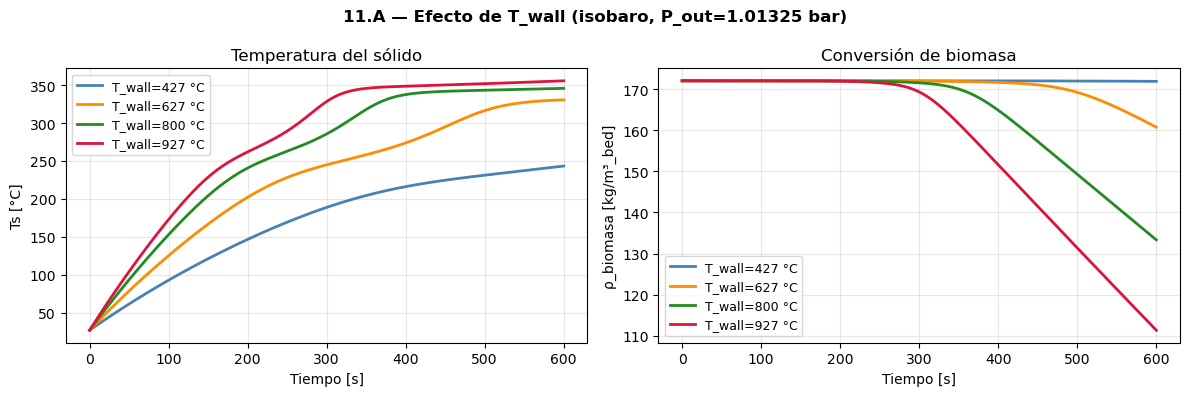

In [49]:
T_MAX_PAR = 600.0   # [s]  tiempo de referencia para 11.A, 11.B y 11.G

T_wall_values = [700.0, 900.0, 1073.15, 1200.0]   # [K]
colors_tw     = ["steelblue", "darkorange", "forestgreen", "crimson"]

results_tw = []
for Tw in T_wall_values:
    tbc = build_thermal_bc_config(
        mode="fixed_twall", Di=Di, Do=Do, e_wall=e_wall,
        T_wall=Tw, k_wall=k_wall, rho_wall=rho_wall, Cp_wall=Cp_wall,
    )
    bc  = build_bc_config(n_comp=nc, P_out_bar=P_out)   # v_out=None: isobaro
    par = {**params_base, "bc_config": bc, "thermal_bc_config": tbc}
    t_, _, g_ = run_step(sv0=sv0, t_max=T_MAX_PAR, params=par,
                         rtol=1e-5, atol=1e-7, n_sec=5, show_progress=False)
    results_tw.append((f"T_wall={Tw-273.15:.0f} °C", t_, g_))
    print(f"  T_wall={Tw-273.15:.0f} °C — Ts_final={g_._Ts_results[-1,0]-273.15:.0f} °C  "
          f"ρ_bio_final={g_._rho_solid_results[-1,0,0]:.1f} kg/m³")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for (lbl, t_, g_), col in zip(results_tw, colors_tw):
    axes[0].plot(t_, g_._Ts_results[:, 0] - 273.15, color=col, lw=2, label=lbl)
    axes[1].plot(t_, g_._rho_solid_results[:, 0, 0], color=col, lw=2, label=lbl)
axes[0].set(xlabel="Tiempo [s]", ylabel="Ts [°C]", title="Temperatura del sólido")
axes[1].set(xlabel="Tiempo [s]", ylabel="ρ_biomasa [kg/m³_bed]", title="Conversión de biomasa")
for ax in axes: ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
fig.suptitle("11.A — Efecto de T_wall (isobaro, P_out=1.01325 bar)", fontweight="bold")
fig.tight_layout(); plt.show()

### 11.B — Efecto del contenido de humedad (mc_wb)

Con mc_wb alto el secado consume energía antes de que llegue la pirólisis.
Con mc_wb ≈ 0 la biomasa entra seca y la pirólisis arranca antes.
Se observan la evolución de Ts y la composición del gas al final de la simulación.

  mc_wb=0 % — Ts_final=350 °C
  mc_wb=15 % — Ts_final=346 °C
  mc_wb=30 % — Ts_final=338 °C


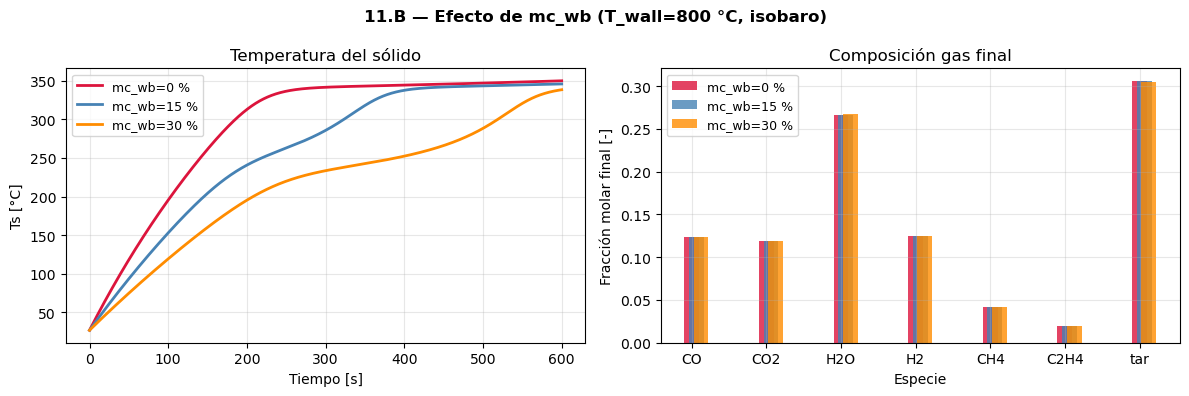

In [50]:
mc_wb_values = [0.0, 0.15, 0.30]
colors_mc    = ["crimson", "steelblue", "darkorange"]

bc_ref  = build_bc_config(n_comp=nc, P_out_bar=P_out)   # v_out=None: isobaro
tbc_ref = build_thermal_bc_config(
    mode="fixed_twall", Di=Di, Do=Do, e_wall=e_wall,
    T_wall=T_wall, k_wall=k_wall, rho_wall=rho_wall, Cp_wall=Cp_wall,
)
results_mc = []
for mc in mc_wb_values:
    rho_moi_mc = rho_bio_dry * mc / (1 - mc) if mc < 1 else 0.0
    ic = build_initial_c_config(
        P_init=P_out, Tg_init=T_init, Ts_init=T_init, y_init=y0,
        rho_biomass_init=rho_bio_dry, rho_char_init=rho_char_0,
        rho_moisture_init=rho_moi_mc,
        n_comp=nc, N=N, prop_gas=prop_gas, epsi_r=epsi_r, gas_T_ref=gas_T_ref,
    )
    par = {**params_base, "bc_config": bc_ref, "thermal_bc_config": tbc_ref}
    t_, _, g_ = run_step(sv0=ic["sv0"], t_max=T_MAX_PAR, params=par,
                         rtol=1e-5, atol=1e-7, n_sec=5, show_progress=False)
    results_mc.append((f"mc_wb={mc*100:.0f} %", t_, g_))
    print(f"  mc_wb={mc*100:.0f} % — Ts_final={g_._Ts_results[-1,0]-273.15:.0f} °C")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for (lbl, t_, g_), col in zip(results_mc, colors_mc):
    axes[0].plot(t_, g_._Ts_results[:, 0] - 273.15, color=col, lw=2, label=lbl)
    y_fin = g_._y_results[-1, :, 0]
    sp_show = [s for s in species if y_fin[species.index(s)] > 1e-3]
    x_pos = [i + [0, 0.25, 0.5][results_mc.index((lbl, t_, g_))] * 0.25 for i in range(len(sp_show))]
    axes[1].bar(x_pos, [y_fin[species.index(s)] for s in sp_show],
                width=0.2, color=col, label=lbl, alpha=0.8)
axes[0].set(xlabel="Tiempo [s]", ylabel="Ts [°C]", title="Temperatura del sólido")
axes[1].set(xlabel="Especie", ylabel="Fracción molar final [-]", title="Composición gas final")
axes[1].set_xticks(range(len(sp_show))); axes[1].set_xticklabels(sp_show)
for ax in axes: ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
fig.suptitle("11.B — Efecto de mc_wb (T_wall=800 °C, isobaro)", fontweight="bold")
fig.tight_layout(); plt.show()

### 11.C — Agotamiento de biomasa y char (T_MAX)

¿Cuándo se agota la biomasa? ¿Y el char?

**Secuencia física del semibatch:**
1. **Secado** (~100–300 s): humedad → H₂O gas. Ts sube lentamente (latente).
2. **Pirólisis** (~300–1600 s): biomasa → gas (CO, CO₂, H₂, CH₄, tar) + char. Ts sube.
3. **Post-pirólisis** (> ~1600 s): biomasa agotada pero **char permanece**. Sin agentes
   gasificantes externos, el char reacciona lentamente con el CO₂ y H₂O producidos por la
   propia pirólisis (Boudouard: char + CO₂ → 2CO; steam-char: char + H₂O → CO + H₂).
   Ts sigue subiendo porque el char absorbe calor del gas (q_gs > 0 mientras Tg > Ts).

Se extiende hasta 3600 s para observar la conversión del char en 3 subplots independientes:
biomasa, char y temperatura del sólido.

  T_MAX=1200 s — ρ_bio=40.88  ρ_char=30.68 kg/m³  Ts_fin=374 °C
  T_MAX=2400 s — ρ_bio=0.00  ρ_char=40.09 kg/m³  Ts_fin=798 °C
  T_MAX=3600 s — ρ_bio=0.00  ρ_char=39.85 kg/m³  Ts_fin=798 °C


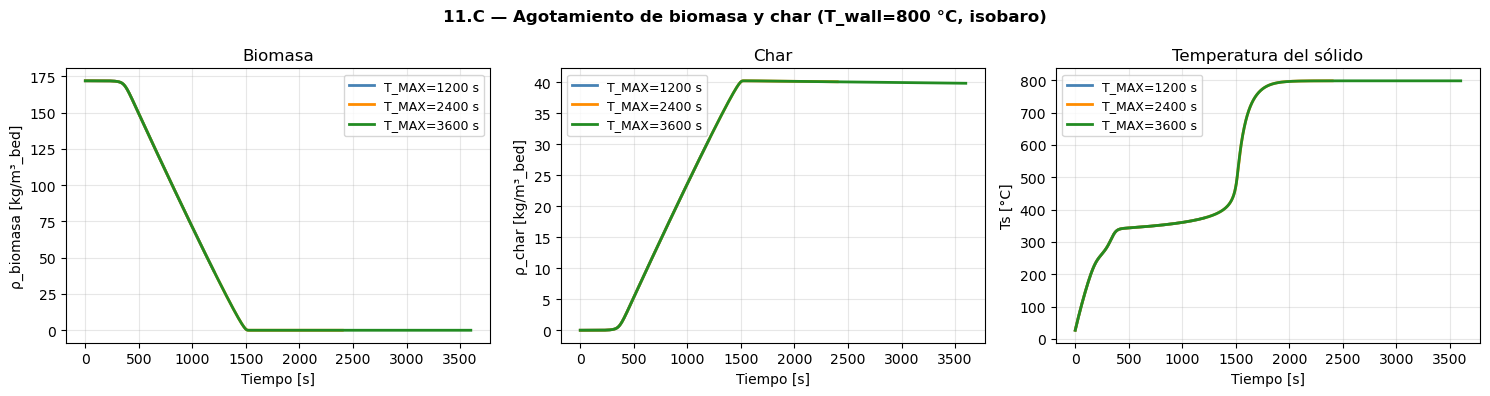

In [51]:
T_max_values = [1200.0, 2400.0, 3600.0]   # [s] — extendido para ver conversión del char
colors_tm    = ["steelblue", "darkorange", "forestgreen"]

bc_ref2  = build_bc_config(n_comp=nc, P_out_bar=P_out)   # v_out=None: isobaro
tbc_ref2 = build_thermal_bc_config(
    mode="fixed_twall", Di=Di, Do=Do, e_wall=e_wall,
    T_wall=T_wall, k_wall=k_wall, rho_wall=rho_wall, Cp_wall=Cp_wall,
)
par_ref2 = {**params_base, "bc_config": bc_ref2, "thermal_bc_config": tbc_ref2}

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)
for tmax, col in zip(T_max_values, colors_tm):
    t_, _, g_ = run_step(sv0=sv0, t_max=tmax, params=par_ref2,
                         rtol=1e-5, atol=1e-7, n_sec=3, show_progress=False)
    lbl = f"T_MAX={tmax:.0f} s"
    axes[0].plot(t_, g_._rho_solid_results[:, 0, 0], color=col, lw=2, label=lbl)
    axes[1].plot(t_, g_._rho_solid_results[:, 1, 0], color=col, lw=2, label=lbl)
    axes[2].plot(t_, g_._Ts_results[:, 0] - 273.15,  color=col, lw=2, label=lbl)
    print(f"  T_MAX={tmax:.0f} s — ρ_bio={g_._rho_solid_results[-1,0,0]:.2f}  "
          f"ρ_char={g_._rho_solid_results[-1,1,0]:.2f} kg/m³  "
          f"Ts_fin={g_._Ts_results[-1,0]-273.15:.0f} °C")

axes[0].set(xlabel="Tiempo [s]", ylabel="ρ_biomasa [kg/m³_bed]", title="Biomasa")
axes[1].set(xlabel="Tiempo [s]", ylabel="ρ_char [kg/m³_bed]",    title="Char")
axes[2].set(xlabel="Tiempo [s]", ylabel="Ts [°C]",               title="Temperatura del sólido")
for ax in axes: ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
fig.suptitle("11.C — Agotamiento de biomasa y char (T_wall=800 °C, isobaro)", fontweight="bold")
fig.tight_layout(); plt.show()

### 11.D — Barrido de v_out + modo isobaro

¿Qué diferencia hay entre venteo proporcional (`v_out > 0`) y el modo isobaro exacto (`v_out=None`)?
Se comparan: batch sellado, venteo lento, venteo rápido y modo isobaro.

- **`v_out > 0`**: venteo proporcional al exceso de presión — la válvula abre si P > P_out.
- **`v_out=None`**: isobaro exacto — la salida compensa exactamente el gas producido por las reacciones.

In [ ]:
v_out_values = [0.0, 0.01, 0.05, 0.50, None]
labels_vo    = ["0.00 (batch)", "0.01 m/s", "0.05 m/s", "0.50 m/s", "None (isobaro)"]
colors_vo    = ["black", "steelblue", "darkorange", "forestgreen", "crimson"]

tbc_ref3 = build_thermal_bc_config(
    mode="fixed_twall", Di=Di, Do=Do, e_wall=e_wall,
    T_wall=T_wall, k_wall=k_wall, rho_wall=rho_wall, Cp_wall=Cp_wall,
)
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=True)
for vo, lbl, col in zip(v_out_values, labels_vo, colors_vo):
    bc_vo  = build_bc_config(n_comp=nc, P_out_bar=P_out, v_out=vo)
    par_vo = {**params_base, "bc_config": bc_vo, "thermal_bc_config": tbc_ref3}
    t_, _, g_ = run_step(sv0=sv0, t_max=T_MAX_PAR, params=par_vo,
                         rtol=1e-5, atol=1e-7, n_sec=5, show_progress=False)
    axes[0].plot(t_, g_._P_results[:, 0],  color=col, lw=2, label=lbl)
    axes[1].plot(t_, g_._v_out_results,    color=col, lw=2, label=lbl)
    print(f"  v_out={lbl:<20} P_max={float(g_._P_results.max()):.3f} bar")

axes[0].axhline(P_out, ls=":", color="gray", alpha=0.7, label=f"P_out={P_out:.2f} bar")
axes[0].set(xlabel="Tiempo [s]", ylabel="P [bar]", title="Presión en el reactor")
axes[1].set(xlabel="Tiempo [s]", ylabel="v_out [m/s]", title="Velocidad de salida")
for ax in axes: ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
fig.suptitle("11.D — Barrido de v_out + modo isobaro", fontweight="bold")
fig.tight_layout(); plt.show()

  v_out=0.00 (batch)         P_max=224.151 bar
  v_out=0.01 m/s             P_max=3.603 bar
  v_out=0.05 m/s             P_max=1.963 bar
  v_out=0.50 m/s             P_max=1.172 bar


### 11.F — Barrido de Cv — válvula ISA-75.01

¿Cómo controla el coeficiente de válvula `Cv` la respuesta de presión en el semibatch?
Un `Cv` pequeño restringe el caudal → la válvula apenas alivia presión.
Un `Cv` grande permite gran caudal ante pequeño ΔP → la presión se mantiene próxima a P_out.

In [ ]:
Cv_values  = [0.05, 0.5, 2.0, 10.0]
labels_cv  = ["Cv=0.05 (muy restrictiva)", "Cv=0.5", "Cv=2.0", "Cv=10.0 (muy permeable)"]
colors_cv  = ["steelblue", "darkorange", "forestgreen", "crimson"]

tbc_ref5 = build_thermal_bc_config(
    mode="fixed_twall", Di=Di, Do=Do, e_wall=e_wall,
    T_wall=T_wall, k_wall=k_wall, rho_wall=rho_wall, Cp_wall=Cp_wall,
)
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=True)
for cv, lbl, col in zip(Cv_values, labels_cv, colors_cv):
    bc_cv  = build_bc_config(n_comp=nc, P_out_bar=P_out, Cv=cv)
    par_cv = {**params_base, "bc_config": bc_cv, "thermal_bc_config": tbc_ref5}
    t_, _, g_ = run_step(sv0=sv0, t_max=T_MAX_PAR, params=par_cv,
                         rtol=1e-5, atol=1e-7, n_sec=5, show_progress=False)
    axes[0].plot(t_, g_._P_results[:, 0],  color=col, lw=2, label=lbl)
    axes[1].plot(t_, g_._v_out_results,    color=col, lw=2, label=lbl)
    print(f"  {lbl:<30}  P_max={float(g_._P_results.max()):.3f} bar  "
          f"v_out_max={float(g_._v_out_results.max()):.4f} m/s")

axes[0].axhline(P_out, ls=":", color="gray", alpha=0.7, label=f"P_out={P_out:.2f} bar")
axes[0].set(xlabel="Tiempo [s]", ylabel="P [bar]", title="Presión en el reactor")
axes[1].set(xlabel="Tiempo [s]", ylabel="v_out [m/s]", title="Velocidad de salida (ISA)")
for ax in axes: ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
fig.suptitle("11.F — Barrido de Cv: respuesta de la válvula ISA-75.01", fontweight="bold")
fig.tight_layout(); plt.show()

### 11.G — Efecto de la presión de consigna (P_out)

Se varía la presión de referencia de la válvula de alivio (P_out).
Con P_out > P_atm el reactor opera a sobrepresión: el gas se acumula hasta superar
ese umbral, lo que modifica las concentraciones absolutas y puede afectar a la cinética.

In [ ]:
P_out_values  = [1.01325, 2.0, 5.0]   # [bar]
labels_po     = ["1.01 bar (atm)", "2.0 bar", "5.0 bar"]
colors_po     = ["steelblue", "darkorange", "crimson"]

tbc_ref4 = build_thermal_bc_config(
    mode="fixed_twall", Di=Di, Do=Do, e_wall=e_wall,
    T_wall=T_wall, k_wall=k_wall, rho_wall=rho_wall, Cp_wall=Cp_wall,
)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for po, lbl, col in zip(P_out_values, labels_po, colors_po):
    # Condición inicial a P_out (presurizado desde el inicio)
    ic_po = build_initial_c_config(
        P_init=po, Tg_init=T_init, Ts_init=T_init, y_init=y0,
        rho_biomass_init=rho_bio_0, rho_char_init=rho_char_0,
        rho_moisture_init=rho_moi_0,
        n_comp=nc, N=N, prop_gas=prop_gas, epsi_r=epsi_r, gas_T_ref=gas_T_ref,
    )
    bc_po  = build_bc_config(n_comp=nc, P_out_bar=po)   # v_out=None: isobaro a P_out
    par_po = {**params_base, "bc_config": bc_po, "thermal_bc_config": tbc_ref4}
    t_, _, g_ = run_step(sv0=ic_po["sv0"], t_max=T_MAX_PAR, params=par_po,
                         rtol=1e-5, atol=1e-7, n_sec=5, show_progress=False)
    axes[0].plot(t_, g_._P_results[:, 0], color=col, lw=2, label=lbl)
    y_fin = g_._y_results[-1, :, 0]
    sp_show = ["CO", "CO2", "H2O", "H2", "CH4", "tar"]
    axes[1].bar([i + P_out_values.index(po)*0.25 for i in range(len(sp_show))],
                [y_fin[species.index(s)] for s in sp_show],
                width=0.22, color=col, label=lbl, alpha=0.85)
    print(f"  P_out={lbl:<15} P_max={float(g_._P_results.max()):.3f} bar  "
          f"Ts_final={g_._Ts_results[-1,0]-273.15:.0f} °C")

axes[0].set(xlabel="Tiempo [s]", ylabel="P [bar]", title="Presión en el reactor")
axes[1].set(xlabel="Especie", ylabel="Fracción molar final [-]", title="Composición gas final")
axes[1].set_xticks(range(len(sp_show))); axes[1].set_xticklabels(sp_show)
for ax in axes: ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
fig.suptitle("11.G — Efecto de P_out: ¿cómo cambia la pirólisis a mayor presión? (isobaro)",
             fontweight="bold")
fig.tight_layout(); plt.show()